#### RNN Model decompositions

<b> List of functions <br>

1. In case of variable time decisions
   1. Segment into epochs
   2. Look at MI in each epoch
   3. Information Decomposition for each epoch
   4. Compute optimal binning strategy
   5. Bayes signal binning
2. In case of constant time decisions
   1. Look at information content in each time step
   2. Report similar analyses


In [5]:
# compute the decision time and model mutual information, transfer entropy, etc from different realizations of the rnn

import numpy as np
from behavior_models import models
from one.api import ONE
from brainbox.io.one import SessionLoader
import pandas as pd
from joblib import Parallel, delayed
from matplotlib import pyplot as plt
import pickle as pkl

from ibl_info.broja_pid import compute_pid, coinformation, compute_pid_unbiased, unbiasedMI, MI
from idtxl.bivariate_mi import BivariateMI
from idtxl.bivariate_te import BivariateTE
from tqdm import tqdm
import itertools

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import seaborn as sns
from glob import glob
from scipy.special import kl_div
from scipy.stats import gaussian_kde
import re
from prior_localization.functions.behavior_targets import optimal_Bayesian

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/one/alf/files.py:10: FutureWarning: `one.alf.files` will be removed in version 3.0. Use `one.alf.path` instead.
  warnings.warn(
2025-01-09 14:39:14.128 | INFO     | ibl_info.config:<module>:8 - PROJ_ROOT path is: /Users/dkundu/Documents/phd/ibl-partial-info-decomp


In [51]:
# function definitions
def discretize_hidden_state(hidden_state, n_bins=15):
    """
    Discretize the hidden state into equipopulated bins

    Args:
        hidden_state (np.array): activations for neurons x trials
        method (str, optional): how to determine the percenille.
                                Defaults to 'neuron'. Calculate the percentile per neuron
                                Other options: 'all': Calculate the percentile based on the entire dataset
    """

    discrete_data = np.zeros((hidden_state.shape[0], hidden_state.shape[1]))
    # discretize per recorded neuron
    for idx in tqdm(range(hidden_state.shape[0])):

        row = hidden_state[idx, :]
        # bin_edges = np.percentile(row, [20,40,60,80])
        # set bin edges to 4 parts
        # bin_edges = np.percentile(row, [25,50,75])
        # discrete_data[idx, :] = np.digitize(row, bin_edges)
        discrete_row, bin_edges_p = pd.qcut(
            row, q=n_bins, labels=False, duplicates="drop", retbins=True
        )
        discrete_data[idx, :] = discrete_row

    discrete_data = np.nan_to_num(discrete_data, nan=0)
    return discrete_data


def discretize_bayes_signal(signal, n_bins=5):
    """
    Discretize the hidden state into equipopulated bins

    Args:
        signal (np.array): bayes signal, 1 x trials
        method (str, optional): how to determine the percenille.
                                Defaults to 'neuron'. Calculate the percentile per neuron
                                Other options: 'all': Calculate the percentile based on the entire dataset
    """

    discrete_data = np.zeros_like(signal)
    # discretize per recorded neuron

    discrete_row, bin_edges_p = pd.qcut(
        signal, q=n_bins, labels=False, duplicates="drop", retbins=True
    )
    discrete_data = discrete_row

    discrete_data = np.nan_to_num(discrete_data, nan=0)
    return discrete_data


def generate_source_ids(number_of_neurons):
    combinations_neuronids = []
    for x in itertools.combinations(range(number_of_neurons), 2):
        combinations_neuronids.append([x[0], x[1]])

    combinations_neuronids = np.asarray(combinations_neuronids)
    return combinations_neuronids


def compute_information_decomposition(decoding_variable, neural_data):
    # always same region
    # neural data is in neurons x trials
    targets = decoding_variable
    sources = generate_source_ids(neural_data.shape[0])

    pid_information = np.zeros((len(sources), 4))  # neuronsC2 x 4
    coinformation_data = np.zeros((len(sources), 4))  # neuronsC2 x 4

    for idx in tqdm(range(len(sources)), desc="Running for all sources", leave=False):
        s1 = sources[idx][0]
        s2 = sources[idx][1]
        X1 = np.asarray(neural_data[s1, :], dtype=np.int32)
        X2 = np.asarray(neural_data[s2, :], dtype=np.int32)
        Y = np.asarray(targets, dtype=np.int32)
        u1, u2, red, syn = compute_pid_unbiased(Y, X1, X2)
        coinfo, mi_yx1x2, mi_yx1, mi_yx2 = coinformation(Y, X1, X2)
        pid_information[idx, :] = u1, u2, red, syn
        coinformation_data[idx, :] = mi_yx1, mi_yx2, coinfo, mi_yx1x2

    # now to organize this?
    # nah, unique information would just be the mean of the first two
    # red and syn  are fine
    # yx1 and yx2 mutual info are also similar to UI
    # the other two are trivariate

    return pid_information, coinformation_data


def find_optimal_discretization_kfold(X, Y, max_bins=20, n_folds=5, random_state=42):
    """
    Find optimal discretization for multiple features using cross-validation.

    Parameters:
    -----------
    X : array-like of shape (n_timepoints, n_neurons)
        Input features to be discretized.
    Y : array-like of shape (n_timepoints,)
        Target variable.
    max_bins : int, default=20
        Maximum number of bins to consider.
    n_folds : int, default=5
        Number of folds for cross-validation.
    random_state : int, default=42
        Random seed for reproducibility.

    Returns:
    --------
    dict : A dictionary containing:
        - 'optimal_bins': List of optimal bin counts for each feature.
        - 'mi_train_scores': List of mutual information scores for each feature on training folds.
        - 'mi_test_scores': List of mutual information scores for each feature on validation folds.
    """
    # Flatten Y if it's a 2D array
    Y = Y.ravel()

    # Ensure X is 2D
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # Split the data using KFold
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    mi_train_scores = []
    mi_test_scores = []
    optimal_bin_list = []

    for train_idx, val_idx in tqdm(kf.split(X), desc="Cross-validation folds"):
        X_train, X_val = X[train_idx, :], X[val_idx, :]
        y_train, y_val = Y[train_idx], Y[val_idx]

        # Store MI scores for each bin count
        feature_mi_train = []
        feature_mi_test = []
        optimal_bins_per_feature = []

        for feature_idx in range(X.shape[1]):
            # Extract a single feature
            X_train_feature = X_train[:, feature_idx]
            X_val_feature = X_val[:, feature_idx]

            # Optimize bins for this feature
            mi_scores_train = []
            for n_bins in range(2, max_bins + 1):
                # Discretize with current bin count
                discretizer = KBinsDiscretizer(
                    n_bins=n_bins, encode="ordinal", strategy="quantile"
                )
                X_train_discretized = discretizer.fit_transform(
                    X_train_feature.reshape(-1, 1)
                ).ravel()

                # Compute MI on training set
                mi_scores_train.append(MI(X_train_discretized, y_train))

            # Find the optimal bin count for the feature
            optimal_bins = np.argmax(mi_scores_train) + 2  # +2 because bins start from 2
            optimal_bins_per_feature.append(optimal_bins)

            # Evaluate on validation set
            discretizer = KBinsDiscretizer(
                n_bins=optimal_bins, encode="ordinal", strategy="quantile"
            )
            X_val_discretized = discretizer.fit_transform(X_val_feature.reshape(-1, 1)).ravel()
            mi_test = MI(X_val_discretized, y_val)

            # Store MI scores
            feature_mi_train.append(mi_scores_train)
            feature_mi_test.append(mi_test)

        # Append results for this fold
        mi_train_scores.append(feature_mi_train)
        mi_test_scores.append(feature_mi_test)
        optimal_bin_list.append(optimal_bins_per_feature)

    # Format results
    results = {
        "optimal_bins": np.array(optimal_bin_list),
        "mi_train_scores": np.array(mi_train_scores),
        "mi_test_scores": np.array(mi_test_scores),
    }

    return results


def epochs(session_data):

    # t end is always when action has been taken

    t_end = session_data.loc[
        session_data["action_taken"] == 1,
        [
            "block_side",
            "trial_within_session",
            "signed_trial_strength",
            "action_side",
            "trial_side",
            "correct_action_taken",
            "hidden_state",
            "left_stimulus",
            "right_stimulus",
            "rnn_step_index",
            "correct_action_prob",
            "left_action_prob",
            "right_action_prob",
        ],
    ]
    signal = optimal_Bayesian(act=t_end["action_side"].values, side=t_end["trial_side"].values)
    t_end["signed_trial_strength"] /= t_end["signed_trial_strength"].max()
    t_end["bayes_prior"] = signal

    t_0 = session_data.loc[
        session_data["trial_start"] == 1,
        [
            "block_side",
            "trial_within_session",
            "signed_trial_strength",
            "action_side",
            "trial_side",
            "correct_action_taken",
            "hidden_state",
            "left_stimulus",
            "right_stimulus",
            "rnn_step_index",
            "correct_action_prob",
            "left_action_prob",
            "right_action_prob",
            "concordant_trial",
        ],
    ]

    iloc = np.where((session_data["action_taken"] == 1) == True)[0]
    t_penultimate = session_data.iloc[iloc - 1][
        [
            "block_side",
            "trial_within_session",
            "signed_trial_strength",
            "action_side",
            "trial_side",
            "correct_action_taken",
            "hidden_state",
            "left_stimulus",
            "right_stimulus",
            "rnn_step_index",
            "correct_action_prob",
            "left_action_prob",
            "right_action_prob",
            "concordant_trial",
        ]
    ]
    t_penultimate["action_side"] = t_end["action_side"].values

    t_penultimate_non_zero = t_penultimate.loc[
        (t_penultimate["right_stimulus"] != 0) | (t_penultimate["left_stimulus"] != 0)
    ]

    # now for t_end for zero contrast trials, split by correct and incorrect choices
    t_zero_contrast = t_end[t_end["signed_trial_strength"] == 0]

    # find correct and incorrect indices

    hidden_state_t_0 = np.concatenate(t_0["hidden_state"].values)
    hidden_state_t_penultimate = np.concatenate(t_penultimate["hidden_state"].values)
    hidden_state_t_penultimate_non_zero = np.concatenate(
        t_penultimate_non_zero["hidden_state"].values
    )
    hidden_state_t_end = np.concatenate(t_end["hidden_state"].values)
    hidden_state_t_zero_contrast = np.concatenate(t_zero_contrast["hidden_state"].values)

    return (
        t_0,
        t_penultimate,
        t_end,
        t_penultimate_non_zero,
        t_zero_contrast,
        hidden_state_t_0,
        hidden_state_t_penultimate,
        hidden_state_t_penultimate_non_zero,
        hidden_state_t_end,
        hidden_state_t_zero_contrast,
    )

In [105]:
# all pids, also bayes signal, also penultimate steps


def plot_pid(
    Block_side_mean_stack,
    Stim_side_mean_stack,
    Action_side_mean_stack,
    Bayes_mean_stack,
    Block_side_std_stack,
    Stim_side_std_stack,
    Action_side_std_stack,
    Bayes_std_stack,
):
    fig, ax = plt.subplots(figsize=(20, 3), ncols=4, sharey=True, sharex=True)

    ax[0].bar(
        np.arange(2) - 0.25,
        Block_side_mean_stack[2, :],
        width=0.25,
        yerr=Block_side_std_stack[2, :] / 2,
    )
    ax[0].bar(
        np.arange(2), Block_side_mean_stack[3, :], width=0.25, yerr=Block_side_std_stack[3, :] / 2
    )
    ax[0].bar(
        np.arange(2) + 0.25,
        Block_side_mean_stack[-1, :],
        width=0.25,
        yerr=Block_side_std_stack[-1, :] / 2,
    )
    ax[0].set_xticks(np.arange(2), labels=["t0", "t_action"])
    ax[0].set_xlabel("RNN time step")
    ax[0].set_title("Block Side Representation")

    ax[1].bar(
        np.arange(2) - 0.25,
        Stim_side_mean_stack[2, :],
        width=0.25,
        yerr=Stim_side_std_stack[2, :] / 2,
    )
    ax[1].bar(
        np.arange(2), Stim_side_mean_stack[3, :], width=0.25, yerr=Stim_side_std_stack[3, :] / 2
    )
    ax[1].bar(
        np.arange(2) + 0.25,
        Stim_side_mean_stack[-1, :],
        width=0.25,
        yerr=Stim_side_std_stack[-1, :] / 2,
    )
    ax[1].set_xticks(np.arange(2), labels=["t0", "t_action"])
    ax[1].set_xlabel("RNN time step")
    ax[1].set_title("Stim Side Representation")

    ax[2].bar(
        np.arange(2) - 0.25,
        Action_side_mean_stack[2, :],
        width=0.25,
        yerr=Action_side_std_stack[2, :] / 2,
        label="Redundancy",
    )
    ax[2].bar(
        np.arange(2),
        Action_side_mean_stack[3, :],
        width=0.25,
        yerr=Action_side_std_stack[3, :] / 2,
        label="Synergy",
    )
    ax[2].bar(
        np.arange(2) + 0.25,
        Action_side_mean_stack[-1, :],
        width=0.25,
        yerr=Action_side_std_stack[-1, :] / 2,
        label="total MI",
    )
    ax[2].set_xticks(np.arange(2), labels=["t0", "t_action"])
    ax[2].set_xlabel("RNN time step")
    ax[2].set_title("Choice Side Representation")

    # -----------#
    ax[3].bar(
        np.arange(2) - 0.25,
        Bayes_mean_stack[2, :],
        width=0.25,
        yerr=Bayes_std_stack[2, :] / 2,
        label="Redundancy",
    )
    ax[3].bar(
        np.arange(2),
        Bayes_mean_stack[3, :],
        width=0.25,
        yerr=Bayes_std_stack[3, :] / 2,
        label="Synergy",
    )
    ax[3].bar(
        np.arange(2) + 0.25,
        Bayes_mean_stack[-1, :],
        width=0.25,
        yerr=Bayes_std_stack[-1, :] / 2,
        label="total MI",
    )
    ax[3].set_xticks(np.arange(2), labels=["t0", "t_action"])
    ax[3].set_xlabel("RNN time step")
    ax[3].set_title("Bayes Representation")

    plt.legend()


def get_all_pid(
    t_0, t_end, t_penultimate, hidden_state_t_0, hidden_state_t_end, hidden_state_t_penultimate
):

    # discretize
    discretized_hidden_state_t_0 = discretize_hidden_state(hidden_state_t_0.T)
    discretized_hidden_state_t_end = discretize_hidden_state(hidden_state_t_end.T)
    discretized_hidden_state_t_penultimate = discretize_hidden_state(hidden_state_t_penultimate.T)

    # now for bayes signal, discretize all at once
    bayes_target = discretize_bayes_signal(t_end["bayes_prior"].values)

    # subset of t_zero
    matching_indices = t_0[
        t_0["trial_within_session"].isin(t_end["trial_within_session"])
    ].index.tolist()

    subset = t_0.loc[matching_indices]
    hidden_state_t_0_subset = np.concatenate(subset["hidden_state"].values)
    discretized_hidden_state_t_0_subset = discretize_hidden_state(hidden_state_t_0_subset.T)

    # for t0

    pid_information, coinformation_data = compute_information_decomposition(
        t_0["trial_side"].values, discretized_hidden_state_t_0
    )
    trial_side_t0 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(
        t_0["block_side"].values, discretized_hidden_state_t_0
    )
    block_side_t0 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(
        t_end["action_side"].values, discretized_hidden_state_t_0
    )
    action_side_t0 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(
        bayes_target, discretized_hidden_state_t_0_subset
    )

    bayes_t0 = np.hstack([pid_information, coinformation_data])

    # for tend

    pid_information, coinformation_data = compute_information_decomposition(
        t_end["trial_side"].values, discretized_hidden_state_t_end
    )
    trial_side_tend = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(
        t_end["block_side"].values, discretized_hidden_state_t_end
    )
    block_side_tend = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(
        t_end["action_side"].values, discretized_hidden_state_t_end
    )
    action_side_tend = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(
        bayes_target, discretized_hidden_state_t_end
    )

    bayes_tend = np.hstack([pid_information, coinformation_data])

    # compute bayes and hidden state for all

    # compute means for different catagories, and then plot them
    # we could do this stacking, but maybe after computing the means

    trial_side_t0_mean = np.mean(trial_side_t0, axis=0)
    block_side_t0_mean = np.mean(block_side_t0, axis=0)
    trial_side_tend_mean = np.mean(trial_side_tend, axis=0)
    block_side_tend_mean = np.mean(block_side_tend, axis=0)
    action_side_t0_mean = np.mean(action_side_t0, axis=0)
    action_side_tend_mean = np.mean(action_side_tend, axis=0)

    bayes_t0_mean = np.mean(bayes_t0, axis=0)
    bayes_tend_mean = np.mean(bayes_tend, axis=0)

    trial_side_t0_std = np.std(trial_side_t0, axis=0)
    block_side_t0_std = np.std(block_side_t0, axis=0)
    trial_side_tend_std = np.std(trial_side_tend, axis=0)
    block_side_tend_std = np.std(block_side_tend, axis=0)
    action_side_t0_std = np.std(action_side_t0, axis=0)
    action_side_tend_std = np.std(action_side_tend, axis=0)

    bayes_t0_std = np.std(bayes_t0, axis=0)
    bayes_tend_std = np.std(bayes_tend, axis=0)

    # maybe it makes more sense to plot the activity of each unit rather than the

    Block_side_mean_stack = np.stack([block_side_t0_mean, block_side_tend_mean], axis=1)
    Stim_side_mean_stack = np.stack([trial_side_t0_mean, trial_side_tend_mean], axis=1)
    Action_side_mean_stack = np.stack([action_side_t0_mean, action_side_tend_mean], axis=1)
    Bayes_mean_stack = np.stack([bayes_t0_mean, bayes_tend_mean], axis=1)

    Block_side_std_stack = np.stack([block_side_t0_std, block_side_tend_std], axis=1)
    Stim_side_std_stack = np.stack([trial_side_t0_std, trial_side_tend_std], axis=1)
    Action_side_std_stack = np.stack([action_side_t0_std, action_side_tend_std], axis=1)
    Bayes_std_stack = np.stack([bayes_t0_std, bayes_tend_std], axis=1)

    return (
        Block_side_mean_stack,
        Stim_side_mean_stack,
        Action_side_mean_stack,
        Bayes_mean_stack,
        Block_side_std_stack,
        Stim_side_std_stack,
        Action_side_std_stack,
        Bayes_std_stack,
    )

In [52]:
files = glob("../../ann-rnn-modified/data/noisydatachoicee/*.pkl")

# proper regex sort
numbered_files = [f for f in files if re.search(r"\d+.pkl$", f)]
sorted_files = sorted(numbered_files, key=lambda x: int(re.search(r"(\d+).pkl$", x).group(1)))
# load all but the first one
# we can rewrite this into a function later

with open(sorted_files[-1], "rb") as f:
    data = pkl.load(f)
session_data = data["session_data"]

In [53]:
(
    t_0,
    t_penultimate,
    t_end,
    t_penultimate_non_zero,
    t_zero_contrast,
    hidden_state_t_0,
    hidden_state_t_penultimate,
    hidden_state_t_penultimate_non_zero,
    hidden_state_t_end,
    hidden_state_t_zero_contrast,
) = epochs(session_data)

In [ ]:
# 83 percent correct action taken for 10000 iterations of training

In [83]:
# plot alles

results_trial_side = find_optimal_discretization_kfold(hidden_state_t_0, t_0["trial_side"].values)
results_block_side = find_optimal_discretization_kfold(hidden_state_t_0, t_0["block_side"].values)


# subset
matching_indices = t_0[
    t_0["trial_within_session"].isin(t_end["trial_within_session"])
].index.tolist()

subset = t_0.loc[matching_indices]
hidden_state_t_0_subset = np.concatenate(subset["hidden_state"].values)
bayes_target = discretize_bayes_signal(t_end["bayes_prior"].values)
results_bayes_prior = find_optimal_discretization_kfold(hidden_state_t_0_subset, bayes_target)

Cross-validation folds: 5it [00:02,  2.14it/s]
Cross-validation folds: 5it [00:02,  2.16it/s]
Cross-validation folds: 5it [00:02,  2.22it/s]


In [84]:
results_trial_side_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["trial_side"].values
)
results_block_side_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["block_side"].values
)
results_left_stimulus_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["left_stimulus"].values
)
results_right_stimlus_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["right_stimulus"].values
)
results_action_side_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["action_side"].values
)


results_bayes_prior_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, bayes_target
)

Cross-validation folds: 5it [00:02,  2.15it/s]
Cross-validation folds: 5it [00:02,  2.19it/s]
Cross-validation folds: 5it [00:02,  2.20it/s]
Cross-validation folds: 5it [00:02,  2.20it/s]
Cross-validation folds: 5it [00:02,  2.19it/s]
Cross-validation folds: 5it [00:02,  2.19it/s]


In [86]:
results_trial_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["trial_side"].values
)
results_block_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["block_side"].values
)
results_left_stimulus_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["left_stimulus"].values
)
results_right_stimlus_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["right_stimulus"].values
)
results_action_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["action_side"].values
)

results_bayes_prior_end = find_optimal_discretization_kfold(hidden_state_t_end, bayes_target)

Cross-validation folds: 5it [00:02,  2.17it/s]
Cross-validation folds: 5it [00:02,  2.18it/s]
Cross-validation folds: 5it [00:02,  2.15it/s]
Cross-validation folds: 5it [00:02,  2.16it/s]
Cross-validation folds: 5it [00:02,  2.16it/s]
Cross-validation folds: 5it [00:02,  2.08it/s]


In [87]:
# now for t zero contrast
results_trial_side_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, t_zero_contrast["trial_side"].values
)
results_block_side_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, t_zero_contrast["block_side"].values
)
results_action_side_end_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, t_zero_contrast["action_side"].values
)

bayes_target_zero_contrast = discretize_bayes_signal(t_zero_contrast["bayes_prior"].values)
results_bayes_prior_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, bayes_target_zero_contrast
)

Cross-validation folds: 5it [00:00,  8.30it/s]
Cross-validation folds: 5it [00:00,  9.30it/s]
Cross-validation folds: 5it [00:00,  9.34it/s]
Cross-validation folds: 5it [00:00,  9.03it/s]


Text(0.5, 0.98, 'MI for T0')

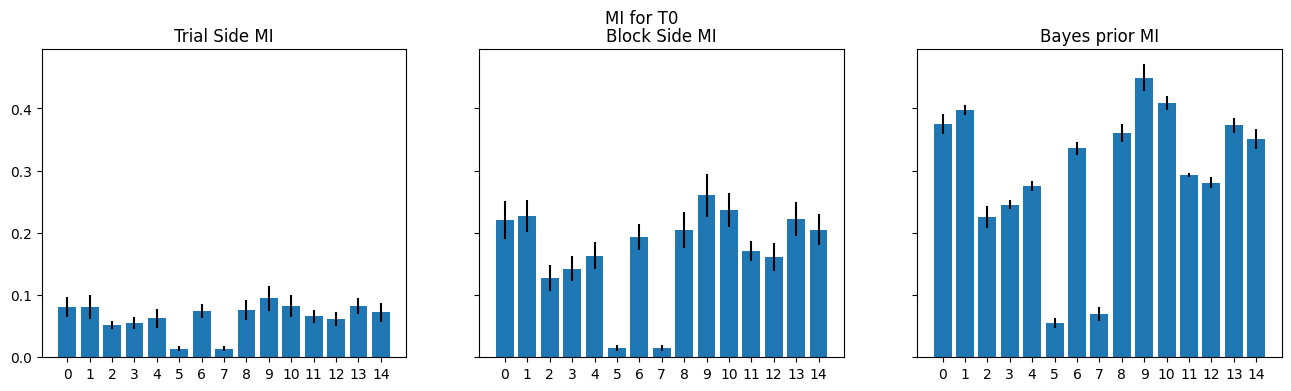

In [91]:
# plots
fig, ax = plt.subplots(figsize=(16, 4), ncols=3, sharey=True, sharex=True)
ax[0].bar(
    np.arange(15),
    results_trial_side["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side["mi_test_scores"].std(axis=0),
)
ax[1].bar(
    np.arange(15),
    results_block_side["mi_test_scores"].mean(axis=0),
    yerr=results_block_side["mi_test_scores"].std(axis=0),
)

ax[2].bar(
    np.arange(15),
    results_bayes_prior["mi_test_scores"].mean(axis=0),
    yerr=results_bayes_prior["mi_test_scores"].std(axis=0),
)
ax[1].set_xticks(np.arange(15))
ax[0].set_title("Trial Side MI")
ax[1].set_title("Block Side MI")
ax[2].set_title("Bayes prior MI")
plt.suptitle("MI for T0")

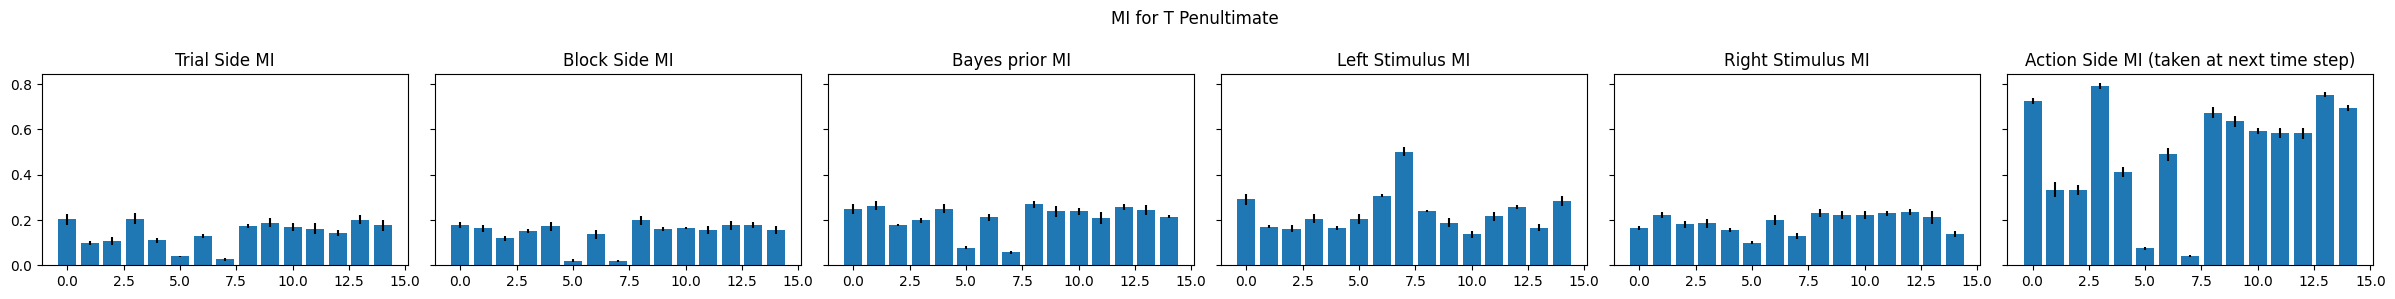

In [94]:
fig, ax = plt.subplots(figsize=(24, 3), ncols=6, sharey=True, sharex=True)

ax[0].bar(
    np.arange(15),
    results_trial_side_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_penultimate["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(15),
    results_block_side_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_penultimate["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(15),
    results_bayes_prior_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_bayes_prior_penultimate["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Bayes prior MI")

ax[3].bar(
    np.arange(15),
    results_left_stimulus_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_left_stimulus_penultimate["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Left Stimulus MI")

ax[4].bar(
    np.arange(15),
    results_right_stimlus_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_right_stimlus_penultimate["mi_test_scores"].std(axis=0),
)
ax[4].set_title("Right Stimulus MI")


ax[5].bar(
    np.arange(15),
    results_action_side_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_penultimate["mi_test_scores"].std(axis=0),
)
ax[5].set_title("Action Side MI (taken at next time step)")

plt.suptitle("MI for T Penultimate")
plt.tight_layout()

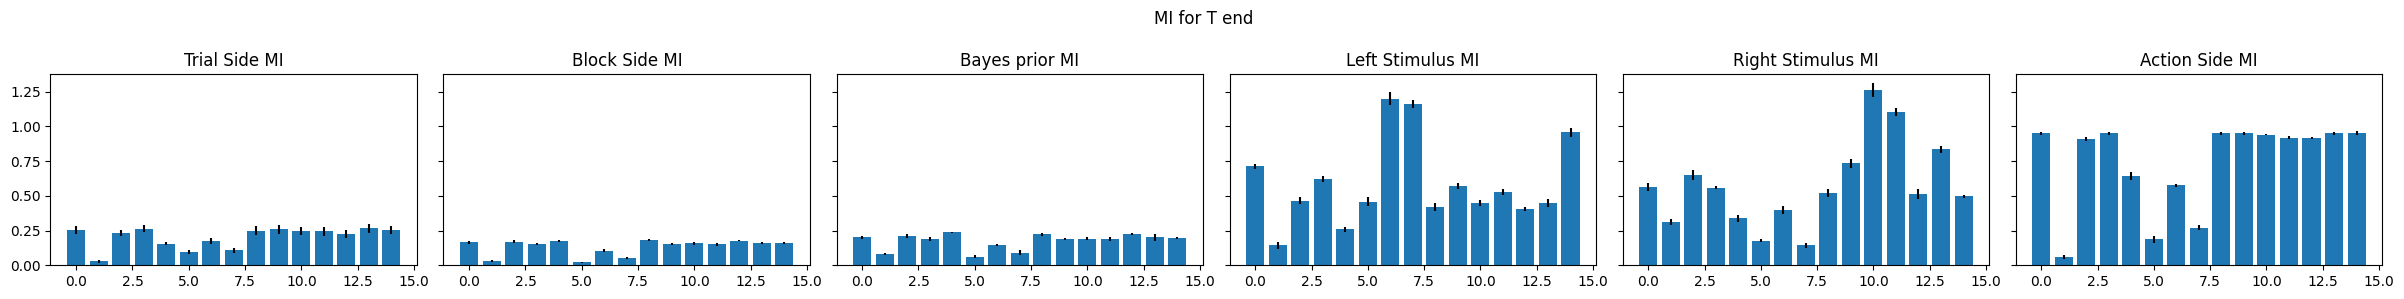

In [100]:
fig, ax = plt.subplots(figsize=(24, 3), ncols=6, sharey=True, sharex=True)

ax[0].bar(
    np.arange(15),
    results_trial_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_end["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(15),
    results_block_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_end["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(15),
    results_bayes_prior_end["mi_test_scores"].mean(axis=0),
    yerr=results_bayes_prior_end["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Bayes prior MI")

ax[3].bar(
    np.arange(15),
    results_left_stimulus_end["mi_test_scores"].mean(axis=0),
    yerr=results_left_stimulus_end["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Left Stimulus MI")

ax[4].bar(
    np.arange(15),
    results_right_stimlus_end["mi_test_scores"].mean(axis=0),
    yerr=results_right_stimlus_end["mi_test_scores"].std(axis=0),
)
ax[4].set_title("Right Stimulus MI")


ax[5].bar(
    np.arange(15),
    results_action_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_end["mi_test_scores"].std(axis=0),
)
ax[5].set_title("Action Side MI")

plt.suptitle("MI for T end")
plt.tight_layout()

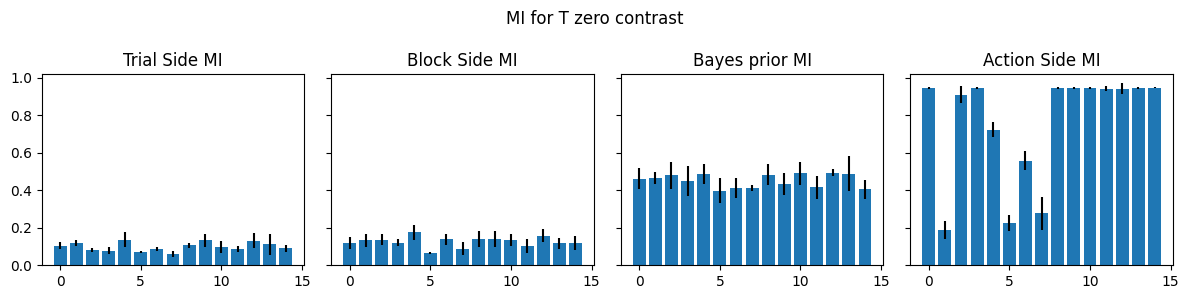

In [99]:
fig, ax = plt.subplots(figsize=(12, 3), ncols=4, sharey=True, sharex=True)

ax[0].bar(
    np.arange(15),
    results_trial_side_zero_contrast["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_zero_contrast["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(15),
    results_block_side_zero_contrast["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_zero_contrast["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(15),
    results_bayes_prior_zero_contrast["mi_test_scores"].mean(axis=0),
    yerr=results_bayes_prior_zero_contrast["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Bayes prior MI")


ax[3].bar(
    np.arange(15),
    results_action_side_end_zero_contrast["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_end_zero_contrast["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Action Side MI")

plt.suptitle("MI for T zero contrast")
plt.tight_layout()

In [106]:
(
    Block_side_mean_stack,
    Stim_side_mean_stack,
    Action_side_mean_stack,
    Bayes_mean_stack,
    Block_side_std_stack,
    Stim_side_std_stack,
    Action_side_std_stack,
    Bayes_std_stack,
) = get_all_pid(
    t_0, t_end, t_penultimate, hidden_state_t_0, hidden_state_t_end, hidden_state_t_penultimate
)

100%|██████████| 15/15 [00:00<00:00, 1839.61it/s]


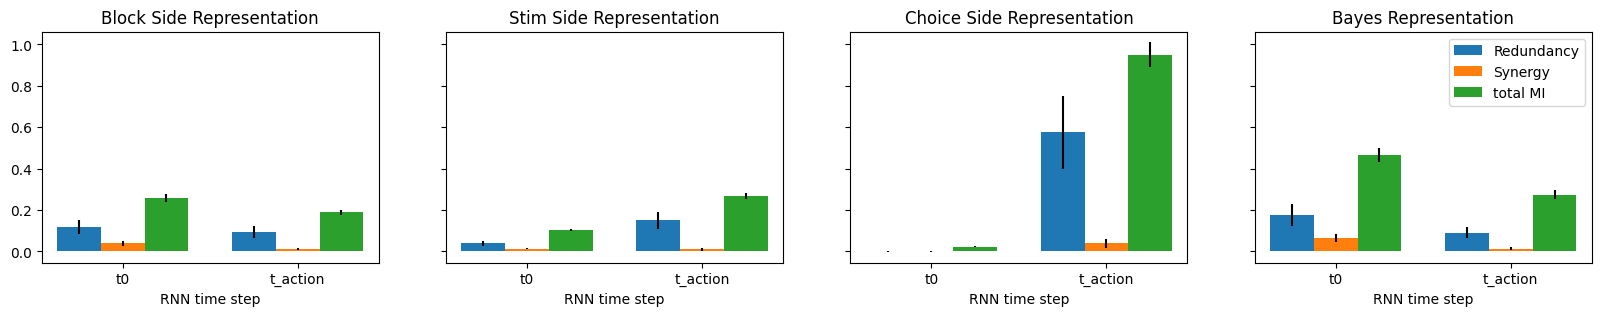

In [107]:
plot_pid(
    Block_side_mean_stack,
    Stim_side_mean_stack,
    Action_side_mean_stack,
    Bayes_mean_stack,
    Block_side_std_stack,
    Stim_side_std_stack,
    Action_side_std_stack,
    Bayes_std_stack,
)

### Limited time ones

In [ ]:
# NOTE: Take 10000 iter of training for the subsequent ones

In [108]:
with open(
    "../../ann-rnn-modified/data/fixed_time_run/hidden_neurons10_integration_6steps/rnn_model_6steps_low_reward.pkl",
    "rb",
) as f:
    data = pkl.load(f)
session_data = data["session_data"]

In [110]:
# get epoch data

(
    t_0,
    t_penultimate,
    t_end,
    t_penultimate_non_zero,
    t_zero_contrast,
    hidden_state_t_0,
    hidden_state_t_penultimate,
    hidden_state_t_penultimate_non_zero,
    hidden_state_t_end,
    hidden_state_t_zero_contrast,
) = epochs(session_data)

In [126]:
# t_1, first time it receives a stimulus

iloc = np.where((session_data["action_taken"] == 1) == True)[0]
t_one = session_data.iloc[iloc - 4][
    [
        "block_side",
        "trial_within_session",
        "signed_trial_strength",
        "action_side",
        "trial_side",
        "correct_action_taken",
        "hidden_state",
        "left_stimulus",
        "right_stimulus",
        "rnn_step_index",
        "correct_action_prob",
        "left_action_prob",
        "right_action_prob",
        "concordant_trial",
    ]
]
t_one["action_side"] = t_end["action_side"].values
hidden_state_t_one = np.concatenate(t_one["hidden_state"].values)

Text(0.5, 1.0, 'Hidden state at t=action')

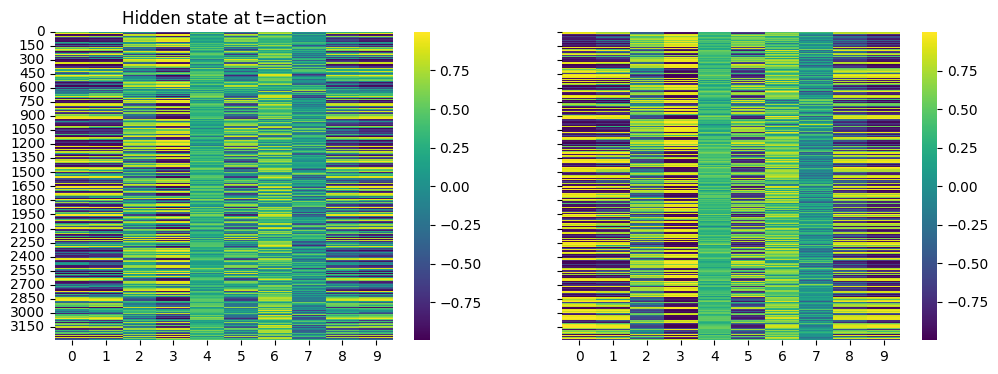

In [149]:
fig, ax = plt.subplots(figsize=(12, 4), ncols=2, sharex=True, sharey=True)
sns.heatmap(hidden_state_t_one, ax=ax[0], cmap="viridis")
ax[0].set_title("Hidden state at t=1")
sns.heatmap(hidden_state_t_end, ax=ax[1], cmap="viridis")
ax[0].set_title("Hidden state at t=action")

In [ ]:
results_trial_side_one = find_optimal_discretization_kfold(
    hidden_state_t_one, t_one["trial_side"].values
)
results_block_side_one = find_optimal_discretization_kfold(
    hidden_state_t_one, t_one["block_side"].values
)
results_left_stimulus_one = find_optimal_discretization_kfold(
    hidden_state_t_one, t_one["left_stimulus"].values
)
results_right_stimlus_one = find_optimal_discretization_kfold(
    hidden_state_t_one, t_one["right_stimulus"].values
)
results_action_side_one = find_optimal_discretization_kfold(
    hidden_state_t_one, t_one["action_side"].values
)


results_bayes_prior_one = find_optimal_discretization_kfold(hidden_state_t_one, bayes_target)

Cross-validation folds: 5it [00:01,  4.59it/s]
Cross-validation folds: 5it [00:01,  4.75it/s]
Cross-validation folds: 5it [00:01,  4.73it/s]
Cross-validation folds: 5it [00:01,  4.62it/s]
Cross-validation folds: 5it [00:01,  4.79it/s]
Cross-validation folds: 5it [00:01,  4.74it/s]


In [114]:
# run all the same analyses, sure!

# plot alles

results_trial_side = find_optimal_discretization_kfold(hidden_state_t_0, t_0["trial_side"].values)
results_block_side = find_optimal_discretization_kfold(hidden_state_t_0, t_0["block_side"].values)


# subset
matching_indices = t_0[
    t_0["trial_within_session"].isin(t_end["trial_within_session"])
].index.tolist()

subset = t_0.loc[matching_indices]
hidden_state_t_0_subset = np.concatenate(subset["hidden_state"].values)
bayes_target = discretize_bayes_signal(t_end["bayes_prior"].values)
results_bayes_prior = find_optimal_discretization_kfold(hidden_state_t_0_subset, bayes_target)

Cross-validation folds: 5it [00:01,  3.95it/s]
Cross-validation folds: 5it [00:01,  4.05it/s]
Cross-validation folds: 5it [00:01,  4.68it/s]


In [115]:
results_trial_side_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["trial_side"].values
)
results_block_side_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["block_side"].values
)
results_left_stimulus_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["left_stimulus"].values
)
results_right_stimlus_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["right_stimulus"].values
)
results_action_side_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["action_side"].values
)


results_bayes_prior_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, bayes_target
)


results_trial_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["trial_side"].values
)
results_block_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["block_side"].values
)
results_left_stimulus_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["left_stimulus"].values
)
results_right_stimlus_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["right_stimulus"].values
)
results_action_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["action_side"].values
)

results_bayes_prior_end = find_optimal_discretization_kfold(hidden_state_t_end, bayes_target)

# now for t zero contrast
results_trial_side_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, t_zero_contrast["trial_side"].values
)
results_block_side_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, t_zero_contrast["block_side"].values
)
results_action_side_end_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, t_zero_contrast["action_side"].values
)

bayes_target_zero_contrast = discretize_bayes_signal(t_zero_contrast["bayes_prior"].values)
results_bayes_prior_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, bayes_target_zero_contrast
)

Cross-validation folds: 5it [00:01,  4.53it/s]
Cross-validation folds: 5it [00:01,  4.79it/s]
Cross-validation folds: 5it [00:01,  4.79it/s]
Cross-validation folds: 5it [00:01,  4.75it/s]
Cross-validation folds: 5it [00:01,  4.80it/s]
Cross-validation folds: 5it [00:01,  4.74it/s]
Cross-validation folds: 5it [00:01,  4.78it/s]
Cross-validation folds: 5it [00:01,  4.78it/s]
Cross-validation folds: 5it [00:01,  4.70it/s]
Cross-validation folds: 5it [00:01,  4.70it/s]
Cross-validation folds: 5it [00:01,  4.74it/s]
Cross-validation folds: 5it [00:01,  4.72it/s]
Cross-validation folds: 5it [00:00, 21.41it/s]
Cross-validation folds: 5it [00:00, 21.37it/s]
Cross-validation folds: 5it [00:00, 21.56it/s]
Cross-validation folds: 5it [00:00, 20.61it/s]


Text(0.5, 0.98, 'MI for T0')

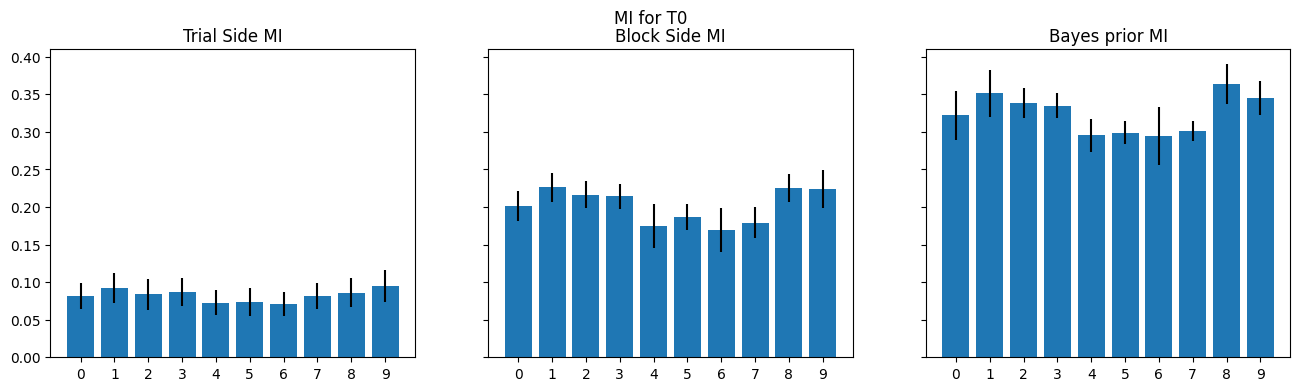

In [120]:
# plots
fig, ax = plt.subplots(figsize=(16, 4), ncols=3, sharey=True, sharex=True)
ax[0].bar(
    np.arange(10),
    results_trial_side["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side["mi_test_scores"].std(axis=0),
)
ax[1].bar(
    np.arange(10),
    results_block_side["mi_test_scores"].mean(axis=0),
    yerr=results_block_side["mi_test_scores"].std(axis=0),
)

ax[2].bar(
    np.arange(10),
    results_bayes_prior["mi_test_scores"].mean(axis=0),
    yerr=results_bayes_prior["mi_test_scores"].std(axis=0),
)
ax[1].set_xticks(np.arange(10))
ax[0].set_title("Trial Side MI")
ax[1].set_title("Block Side MI")
ax[2].set_title("Bayes prior MI")
plt.suptitle("MI for T0")

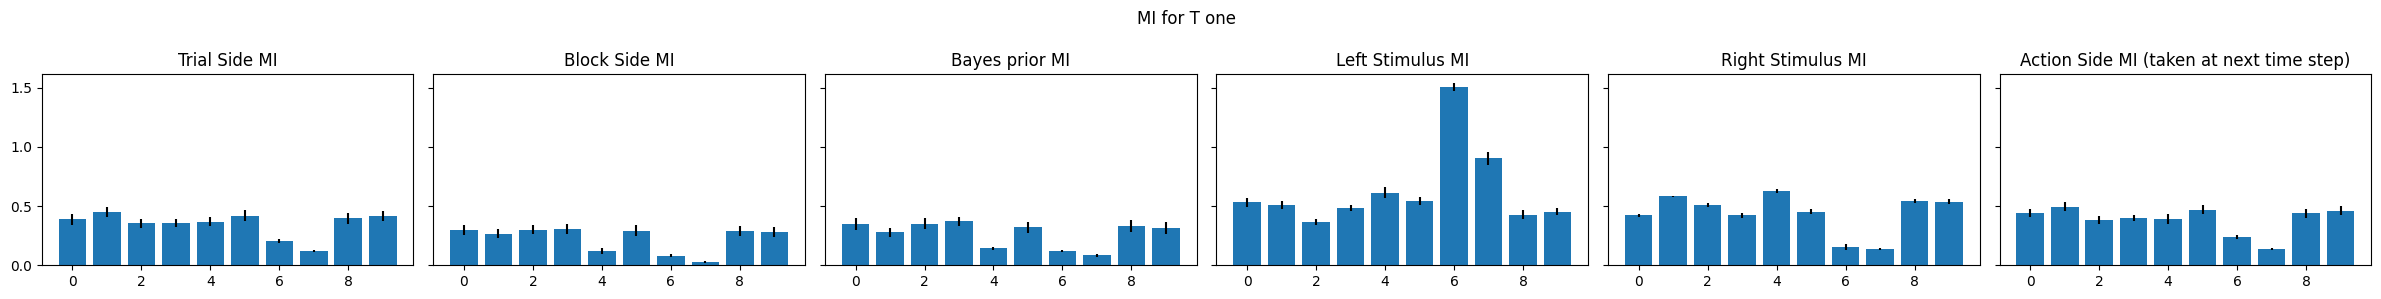

In [129]:
fig, ax = plt.subplots(figsize=(24, 3), ncols=6, sharey=True, sharex=True)

ax[0].bar(
    np.arange(10),
    results_trial_side_one["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_one["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(10),
    results_block_side_one["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_one["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(10),
    results_bayes_prior_one["mi_test_scores"].mean(axis=0),
    yerr=results_bayes_prior_one["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Bayes prior MI")

ax[3].bar(
    np.arange(10),
    results_left_stimulus_one["mi_test_scores"].mean(axis=0),
    yerr=results_left_stimulus_one["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Left Stimulus MI")

ax[4].bar(
    np.arange(10),
    results_right_stimlus_one["mi_test_scores"].mean(axis=0),
    yerr=results_right_stimlus_one["mi_test_scores"].std(axis=0),
)
ax[4].set_title("Right Stimulus MI")


ax[5].bar(
    np.arange(10),
    results_action_side_one["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_one["mi_test_scores"].std(axis=0),
)
ax[5].set_title("Action Side MI (taken at next time step)")

plt.suptitle("MI for T one")
plt.tight_layout()

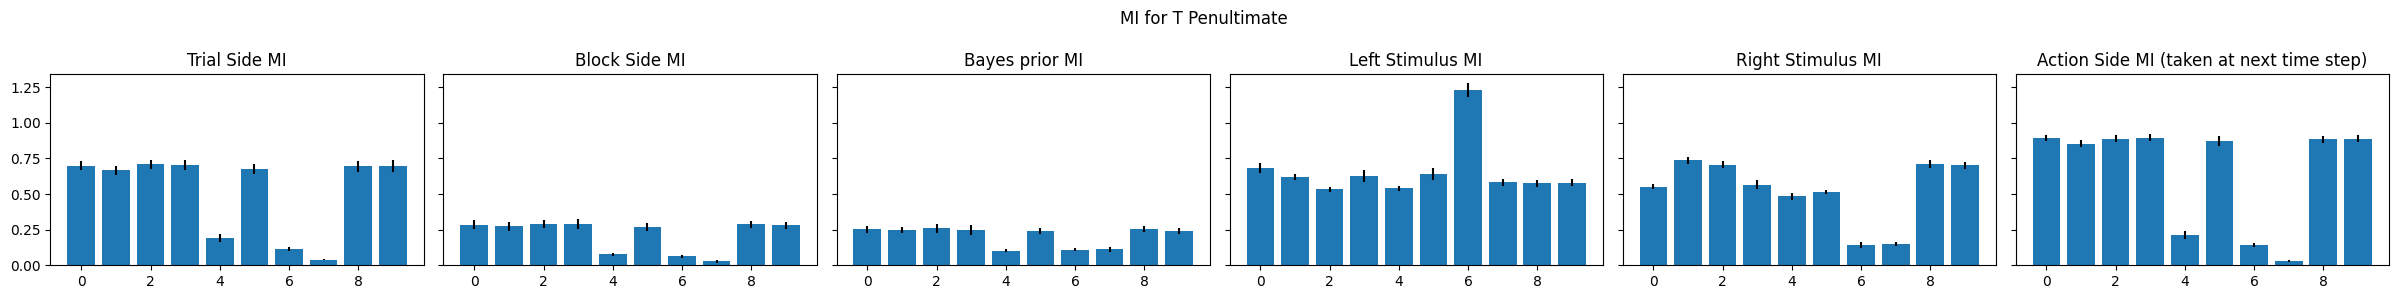

In [121]:
fig, ax = plt.subplots(figsize=(24, 3), ncols=6, sharey=True, sharex=True)

ax[0].bar(
    np.arange(10),
    results_trial_side_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_penultimate["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(10),
    results_block_side_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_penultimate["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(10),
    results_bayes_prior_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_bayes_prior_penultimate["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Bayes prior MI")

ax[3].bar(
    np.arange(10),
    results_left_stimulus_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_left_stimulus_penultimate["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Left Stimulus MI")

ax[4].bar(
    np.arange(10),
    results_right_stimlus_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_right_stimlus_penultimate["mi_test_scores"].std(axis=0),
)
ax[4].set_title("Right Stimulus MI")


ax[5].bar(
    np.arange(10),
    results_action_side_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_penultimate["mi_test_scores"].std(axis=0),
)
ax[5].set_title("Action Side MI (taken at next time step)")

plt.suptitle("MI for T Penultimate")
plt.tight_layout()

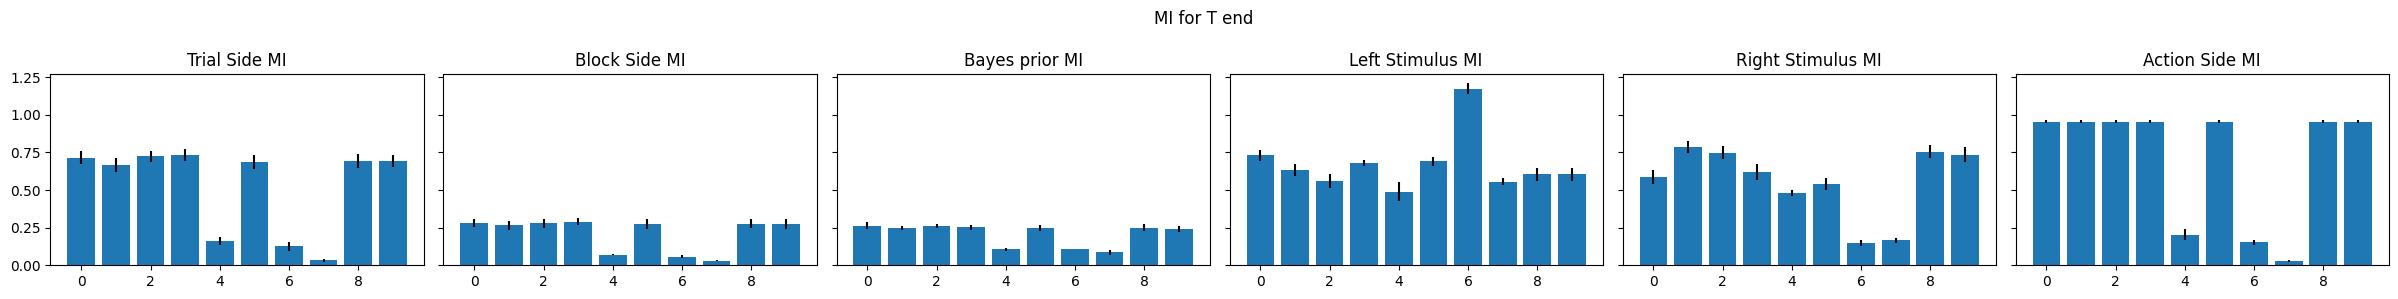

In [122]:
fig, ax = plt.subplots(figsize=(24, 3), ncols=6, sharey=True, sharex=True)

ax[0].bar(
    np.arange(10),
    results_trial_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_end["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(10),
    results_block_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_end["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(10),
    results_bayes_prior_end["mi_test_scores"].mean(axis=0),
    yerr=results_bayes_prior_end["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Bayes prior MI")

ax[3].bar(
    np.arange(10),
    results_left_stimulus_end["mi_test_scores"].mean(axis=0),
    yerr=results_left_stimulus_end["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Left Stimulus MI")

ax[4].bar(
    np.arange(10),
    results_right_stimlus_end["mi_test_scores"].mean(axis=0),
    yerr=results_right_stimlus_end["mi_test_scores"].std(axis=0),
)
ax[4].set_title("Right Stimulus MI")


ax[5].bar(
    np.arange(10),
    results_action_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_end["mi_test_scores"].std(axis=0),
)
ax[5].set_title("Action Side MI")

plt.suptitle("MI for T end")
plt.tight_layout()

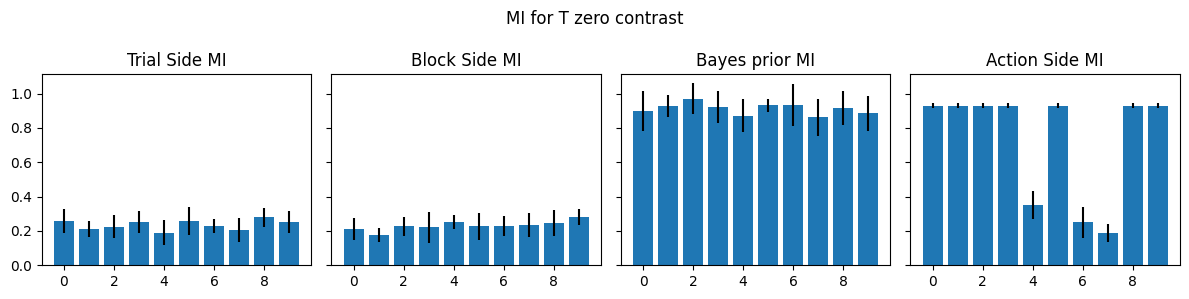

In [123]:
fig, ax = plt.subplots(figsize=(12, 3), ncols=4, sharey=True, sharex=True)

ax[0].bar(
    np.arange(10),
    results_trial_side_zero_contrast["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_zero_contrast["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(10),
    results_block_side_zero_contrast["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_zero_contrast["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(10),
    results_bayes_prior_zero_contrast["mi_test_scores"].mean(axis=0),
    yerr=results_bayes_prior_zero_contrast["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Bayes prior MI")


ax[3].bar(
    np.arange(10),
    results_action_side_end_zero_contrast["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_end_zero_contrast["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Action Side MI")

plt.suptitle("MI for T zero contrast")
plt.tight_layout()

In [124]:
(
    Block_side_mean_stack,
    Stim_side_mean_stack,
    Action_side_mean_stack,
    Bayes_mean_stack,
    Block_side_std_stack,
    Stim_side_std_stack,
    Action_side_std_stack,
    Bayes_std_stack,
) = get_all_pid(
    t_0, t_end, t_penultimate, hidden_state_t_0, hidden_state_t_end, hidden_state_t_penultimate
)

100%|██████████| 10/10 [00:00<00:00, 1828.54it/s]


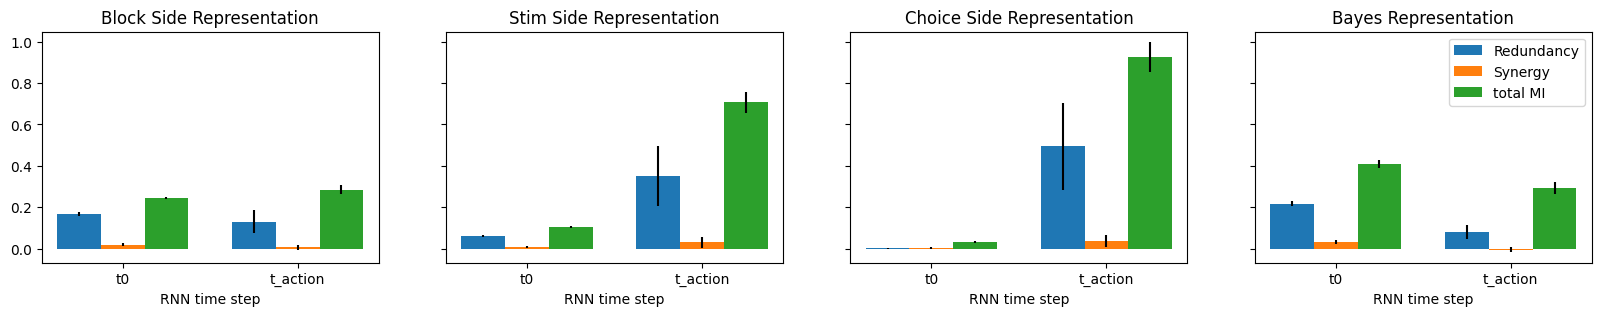

In [125]:
plot_pid(
    Block_side_mean_stack,
    Stim_side_mean_stack,
    Action_side_mean_stack,
    Bayes_mean_stack,
    Block_side_std_stack,
    Stim_side_std_stack,
    Action_side_std_stack,
    Bayes_std_stack,
)

In [162]:
# track changes


def organize_data(
    results_trial_side_one,
    results_block_side_one,
    results_left_stimulus_one,
    results_right_stimulus_one,
    results_action_side_one,
    results_bayes_prior_one,
    results_trial_side_penultimate,
    results_block_side_penultimate,
    results_left_stimulus_penultimate,
    results_right_stimlus_penultimate,
    results_action_side_penultimate,
    results_bayes_prior_penultimate,
    results_trial_side_end,
    results_block_side_end,
    results_left_stimulus_end,
    results_right_stimlus_end,
    results_action_side_end,
    results_bayes_prior_end,
    idx,
):

    trial_scores_mean = [
        results_trial_side_one["mi_test_scores"][:, idx].mean(axis=0),
        results_trial_side_penultimate["mi_test_scores"][:, idx].mean(axis=0),
        results_trial_side_end["mi_test_scores"][:, idx].mean(axis=0),
    ]
    trial_scores_std = [
        results_trial_side_one["mi_test_scores"][:, idx].std(axis=0),
        results_trial_side_penultimate["mi_test_scores"][:, idx].std(axis=0),
        results_trial_side_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    block_scores_mean = [
        results_block_side_one["mi_test_scores"][:, idx].mean(axis=0),
        results_block_side_penultimate["mi_test_scores"][:, idx].mean(axis=0),
        results_block_side_end["mi_test_scores"][:, idx].mean(axis=0),
    ]
    block_scores_std = [
        results_block_side_one["mi_test_scores"][:, idx].std(axis=0),
        results_block_side_penultimate["mi_test_scores"][:, idx].std(axis=0),
        results_block_side_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    action_scores_mean = [
        results_action_side_one["mi_test_scores"][:, idx].mean(axis=0),
        results_action_side_penultimate["mi_test_scores"][:, idx].mean(axis=0),
        results_action_side_end["mi_test_scores"][:, idx].mean(axis=0),
    ]
    action_scores_std = [
        results_action_side_one["mi_test_scores"][:, idx].std(axis=0),
        results_action_side_penultimate["mi_test_scores"][:, idx].std(axis=0),
        results_action_side_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    left_stimulus_scores_mean = [
        results_left_stimulus_one["mi_test_scores"][:, idx].mean(axis=0),
        results_left_stimulus_penultimate["mi_test_scores"][:, idx].mean(axis=0),
        results_left_stimulus_end["mi_test_scores"][:, idx].mean(axis=0),
    ]

    left_stimulus_scores_std = [
        results_left_stimulus_one["mi_test_scores"][:, idx].std(axis=0),
        results_left_stimulus_penultimate["mi_test_scores"][:, idx].std(axis=0),
        results_left_stimulus_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    right_stimulus_scores_mean = [
        results_right_stimulus_one["mi_test_scores"][:, idx].mean(axis=0),
        results_right_stimlus_penultimate["mi_test_scores"][:, idx].mean(axis=0),
        results_right_stimlus_end["mi_test_scores"][:, idx].mean(axis=0),
    ]

    right_stimulus_scores_std = [
        results_right_stimulus_one["mi_test_scores"][:, idx].std(axis=0),
        results_right_stimlus_penultimate["mi_test_scores"][:, idx].std(axis=0),
        results_right_stimlus_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    bayes_prior_mean = [
        results_bayes_prior_one["mi_test_scores"][:, idx].std(axis=0),
        results_bayes_prior_penultimate["mi_test_scores"][:, idx].std(axis=0),
        results_bayes_prior_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    bayes_prior_std = [
        results_bayes_prior_one["mi_test_scores"][:, idx].std(axis=0),
        results_bayes_prior_penultimate["mi_test_scores"][:, idx].std(axis=0),
        results_bayes_prior_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    return (
        trial_scores_mean,
        trial_scores_std,
        block_scores_mean,
        block_scores_std,
        action_scores_mean,
        action_scores_std,
        left_stimulus_scores_mean,
        left_stimulus_scores_std,
        right_stimulus_scores_mean,
        right_stimulus_scores_std,
        bayes_prior_mean,
        bayes_prior_std,
    )

In [164]:
trial_scores_hp = np.zeros((10, 3))
block_scores_hp = np.zeros((10, 3))
action_scores_hp = np.zeros((10, 3))
left_scores_hp = np.zeros((10, 3))
right_scores_hp = np.zeros((10, 3))
bayes_prior_hp = np.zeros((10, 3))

for idx in range(10):

    # have to reorganize
    (
        trial_scores_mean,
        trial_scores_std,
        block_scores_mean,
        block_scores_std,
        action_scores_mean,
        action_scores_std,
        left_stimulus_scores_mean,
        left_stimulus_scores_std,
        right_stimulus_scores_mean,
        right_stimulus_scores_std,
        bayes_prior_mean,
        bayes_prior_std,
    ) = organize_data(
        results_trial_side_one,
        results_block_side_one,
        results_left_stimulus_one,
        results_right_stimlus_one,
        results_action_side_one,
        results_bayes_prior_one,
        results_trial_side_penultimate,
        results_block_side_penultimate,
        results_left_stimulus_penultimate,
        results_right_stimlus_penultimate,
        results_action_side_penultimate,
        results_bayes_prior_penultimate,
        results_trial_side_end,
        results_block_side_end,
        results_left_stimulus_end,
        results_right_stimlus_end,
        results_action_side_end,
        results_bayes_prior_end,
        idx,
    )

    trial_scores_hp[idx, :] = trial_scores_mean
    block_scores_hp[idx, :] = block_scores_mean
    action_scores_hp[idx, :] = action_scores_mean
    left_scores_hp[idx, :] = left_stimulus_scores_mean
    right_scores_hp[idx, :] = right_stimulus_scores_mean
    bayes_prior_hp[idx, :] = bayes_prior_mean

Text(0.5, 1.0, 'Right stimulus strength')

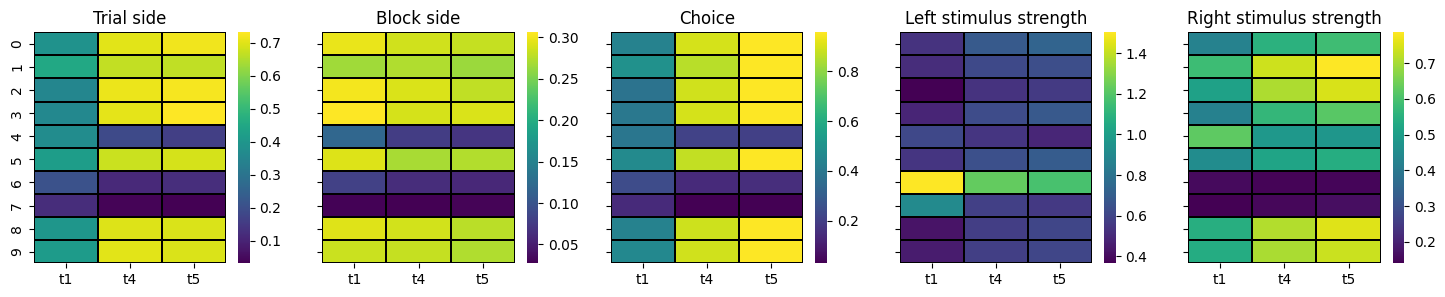

In [174]:
fig, ax = plt.subplots(figsize=(18, 3), ncols=5, sharey=True, sharex=True)


sns.heatmap(trial_scores_hp, ax=ax[0], cmap="viridis", linecolor="k", linewidths=0.25)
ax[0].set_title("Trial side")
sns.heatmap(block_scores_hp, ax=ax[1], cmap="viridis", linecolor="k", linewidths=0.25)
ax[1].set_title("Block side")
sns.heatmap(action_scores_hp, ax=ax[2], cmap="viridis", linecolor="k", linewidths=0.25)
ax[2].set_title("Choice")
sns.heatmap(left_scores_hp, ax=ax[3], cmap="viridis", linecolor="k", linewidths=0.25)
ax[3].set_title("Left stimulus strength")

sns.heatmap(right_scores_hp, ax=ax[4], cmap="viridis", linecolor="k", linewidths=0.25)
ax[4].set_xticks(np.arange(3) + 0.5, ["t1", "t4", "t5"])
ax[4].set_title("Right stimulus strength")

Text(0.5, 1.0, 'Action Side')

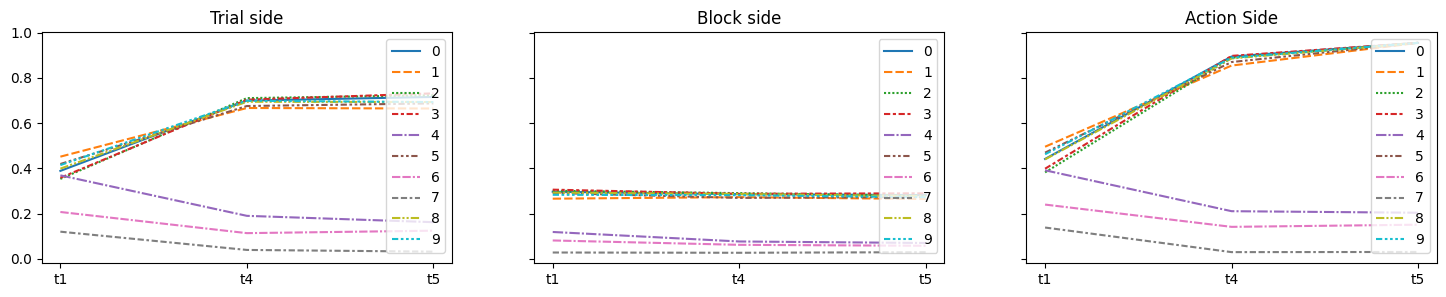

In [190]:
fig, ax = plt.subplots(figsize=(18, 3), ncols=3, sharey=True, sharex=True)
plt.xticks(np.arange(3), ["t1", "t4", "t5"])

sns.lineplot(trial_scores_hp.T, ax=ax[0])
ax[0].set_title("Trial side")

sns.lineplot(block_scores_hp.T, ax=ax[1])
ax[1].set_title("Block side")

sns.lineplot(action_scores_hp.T, ax=ax[2])
ax[2].set_title("Action Side")